 ## 1. Install and load packages                       

In [1]:
# loads packages                                                                             # DESCRIPTION
import numpy as np                                                                           # scientific computing
import pandas as pd                                                                          # tabular data
import matplotlib as mtp                                                                     # visualization
import matplotlib.pyplot as plt                                                              # visualization                                   
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold       # data analysis and machine learning
from sklearn.ensemble import RandomForestClassifier                                         # data analysis and machine learning
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay  # data analysis and machine learning
import os 
from pandas.plotting import scatter_matrix
from sklearn.model_selection import RandomizedSearchCV

## 2. Data Exploration   

In [2]:
#read data in the Pandas 
df = pd.read_csv("FKKD_2021_to_2024_valid.csv")

In [3]:
#Get first 5 samples
df.head()

,Datetime,Temp,DP,RH,Wind Speed,Pressure,Visibility,Rain
0,2021-01-01 00:00:00,26,26,100.0,0,1010,7000.0,0
1,2021-01-01 02:00:00,26,26,100.0,2,1009,2500.0,0
2,2021-01-01 03:00:00,25,25,100.0,2,1010,6000.0,0
3,2021-01-01 04:00:00,25,25,100.0,0,1009,6000.0,0
4,2021-01-01 05:00:00,25,25,100.0,0,1010,6000.0,0


In [4]:
#Get last 5 samples
df.tail()

,Datetime,Temp,DP,RH,Wind Speed,Pressure,Visibility,Rain
23079,2024-12-31 01:00:00,27,26,94.3,0,1010,8000.0,0
23080,2024-12-31 02:00:00,26,25,94.2,2,1009,9999.0,0
23081,2024-12-31 03:00:00,26,25,94.2,1,1009,9999.0,0
23082,2024-12-31 04:00:00,25,25,100.0,1,1009,9999.0,0
23083,2024-12-31 08:00:00,29,25,79.0,2,1011,4000.0,0


In [5]:
#Get shape of data
df.shape

(23084, 8)

In [6]:
#Check data consistency
df.dtypes

Datetime       object
Temp            int64
DP              int64
RH            float64
Wind Speed      int64
Pressure        int64
Visibility    float64
Rain            int64
dtype: object

In [7]:
#Get information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23084 entries, 0 to 23083
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Datetime    23084 non-null  object 
 1   Temp        23084 non-null  int64  
 2   DP          23084 non-null  int64  
 3   RH          23084 non-null  float64
 4   Wind Speed  23084 non-null  int64  
 5   Pressure    23084 non-null  int64  
 6   Visibility  22992 non-null  float64
 7   Rain        23084 non-null  int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 1.4+ MB


In [8]:
#Desciptive stattistic
df.describe()

,Temp,DP,RH,Wind Speed,Pressure,Visibility,Rain
count,23084.000000,23084.000000,23084.000000,23084.000000,23084.000000,22992.000000,23084.000000
mean,27.311774,24.835081,87.467514,2.350806,1010.684024,8315.623956,0.184370
std,2.940434,1.141984,12.412181,1.688946,2.215478,2398.400169,0.387794
min,21.000000,19.000000,41.200000,0.000000,1004.000000,300.000000,0.000000
25%,25.000000,24.000000,79.000000,1.000000,1009.000000,7000.000000,0.000000
50%,26.000000,25.000000,94.100000,2.000000,1011.000000,9999.000000,0.000000
75%,29.000000,26.000000,100.000000,3.000000,1012.000000,9999.000000,0.000000
max,37.000000,29.000000,100.000000,18.000000,1018.000000,9999.000000,1.000000


In [9]:
#Get columns in the data
df.columns.to_list()

['Datetime',
 'Temp',
 'DP',
 'RH',
 'Wind Speed',
 'Pressure',
 'Visibility',
 'Rain']

## 3. Data Preparation   

In [10]:
df.drop(["Datetime", "DP"], axis = 1, inplace=True)
df.rename(columns={"Rain": "Target"}, inplace=True)
df.rename(columns={"Temp": "Temperature"}, inplace=True)
df.rename(columns={"RH":"Relative Humidity"}, inplace=True)

In [11]:
df.head()

,Temperature,Relative Humidity,Wind Speed,Pressure,Visibility,Target
0,26,100.0,0,1010,7000.0,0
1,26,100.0,2,1009,2500.0,0
2,25,100.0,2,1010,6000.0,0
3,25,100.0,0,1009,6000.0,0
4,25,100.0,0,1010,6000.0,0


In [12]:
df.tail()

,Temperature,Relative Humidity,Wind Speed,Pressure,Visibility,Target
23079,27,94.3,0,1010,8000.0,0
23080,26,94.2,2,1009,9999.0,0
23081,26,94.2,1,1009,9999.0,0
23082,25,100.0,1,1009,9999.0,0
23083,29,79.0,2,1011,4000.0,0


In [13]:
# Get number of sample for each class
classes = df.groupby("Target").size()

In [14]:
print(classes)

Target
0    18828
1     4256
dtype: int64


<div style="background-color: #ffa64d; padding: 10px; border-left: 5px solid #cc6600; margin-bottom: 10px;">

Class imbalance in the training data : 
- 23% RAIN  
- 77% NO RAIN
    
</div>

In [15]:
#Correlation Matrix
correlations  = df.corr(method = "pearson")

In [16]:
correlations

,Temperature,Relative Humidity,Wind Speed,Pressure,Visibility,Target
Temperature,1.000000,-0.919830,0.384150,-0.381224,0.072336,-0.290523
Relative Humidity,-0.919830,1.000000,-0.466137,0.273847,-0.078337,0.238455
Wind Speed,0.384150,-0.466137,1.000000,-0.132140,0.040282,0.065547
Pressure,-0.381224,0.273847,-0.132140,1.000000,-0.149316,0.238748
Visibility,0.072336,-0.078337,0.040282,-0.149316,1.000000,-0.154893
Target,-0.290523,0.238455,0.065547,0.238748,-0.154893,1.000000


In [17]:
skews = df.skew()

In [18]:
print(skews)

Temperature          0.699542
Relative Humidity   -0.823535
Wind Speed           0.940966
Pressure            -0.081334
Visibility          -1.340699
Target               1.627963
dtype: float64


In [19]:
## 4. Data Visualisation   

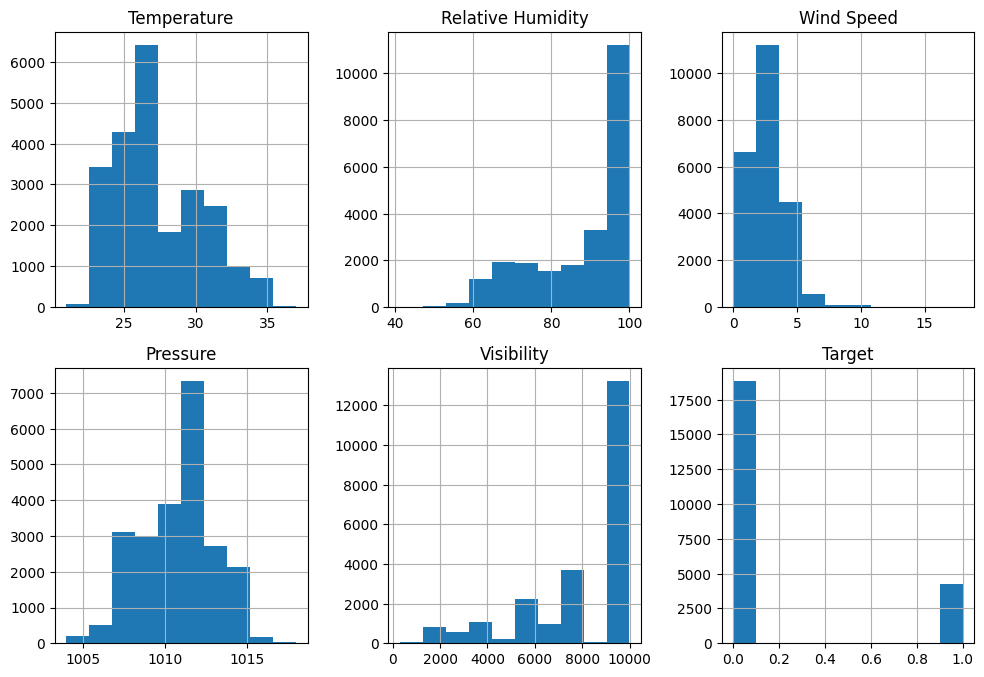

In [20]:
df.hist( figsize=(10, 10), layout = (3,3), sharex=False)
plt.tight_layout()
plt.show()

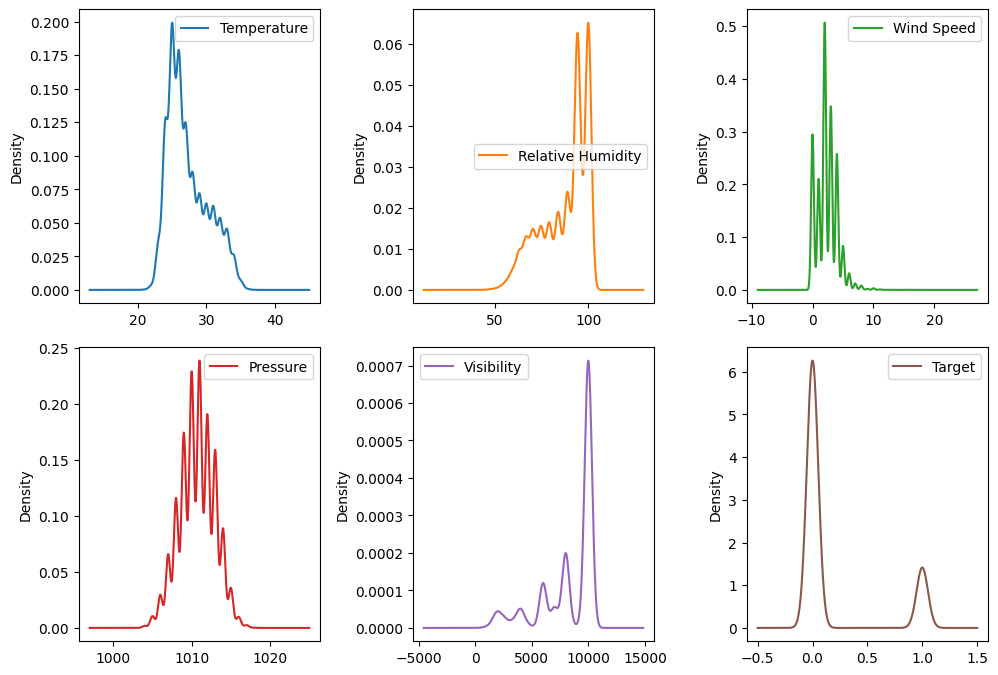

In [21]:
df.plot(kind='density', subplots=True, figsize=(10, 10), layout = (3,3), sharex=False)
plt.tight_layout()
plt.show()

<div style="background-color: #ffa64d; padding: 10px; border-left: 5px solid #cc6600; margin-bottom: 10px;">

Data do not follow normal distribution  : 
- Temperature, Wind Speed, Targer are Left Skew,  
- Relative Humidity, Pressure and Visibility are Right skew
    
</div>

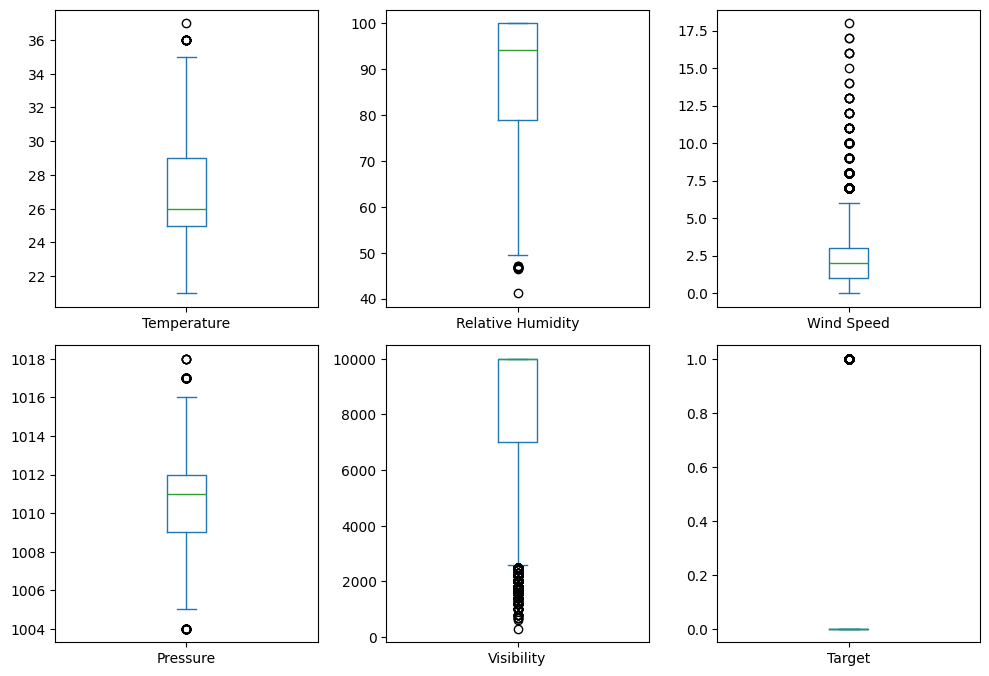

In [22]:
# Plot BBX
df.plot(kind='box', subplots=True,figsize=(10, 10), layout = (3,3),sharex=False, sharey=False )
plt.tight_layout()
plt.show()

<div style="background-color: #ffa64d; padding: 10px; border-left: 5px solid #cc6600; margin-bottom: 10px;">

- Temperature, Pressure , Target,  Relative Humidity have few outlier
-  Wind Speed, Visibility  have many outlier
    
</div>

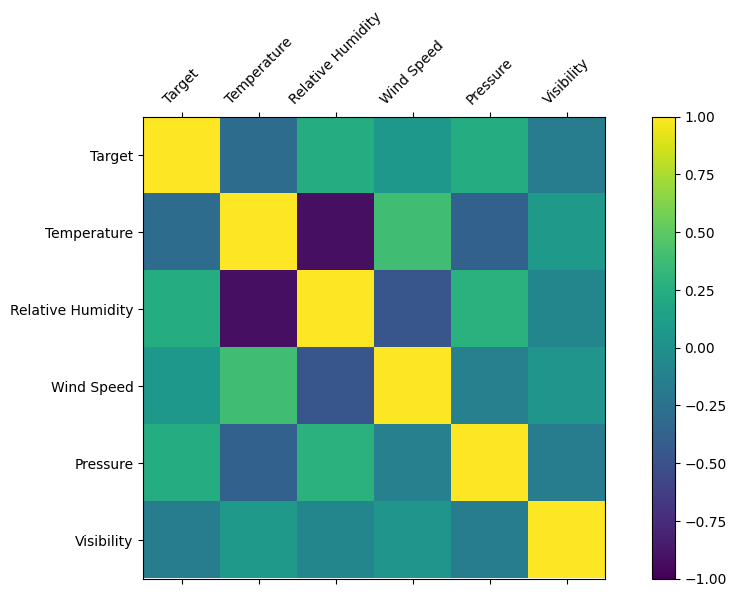

In [23]:
names =['Target', 'Temperature','Relative Humidity','Wind Speed','Pressure','Visibility']
correlations = df[['Target', 'Temperature','Relative Humidity','Wind Speed','Pressure','Visibility']].corr() 
fig = plt.figure(figsize=(12, 6)) 
ax = fig.add_subplot(111) 
cax = ax.matshow(correlations, vmin=-1, vmax=1) 
fig.colorbar(cax) 
ticks = np.arange(0,6,1)
ax.set_xticks(ticks) 
ax.set_yticks(ticks) 
ax.set_xticklabels(names, rotation=45)
ax.set_yticklabels(names) 
plt.show()

[]

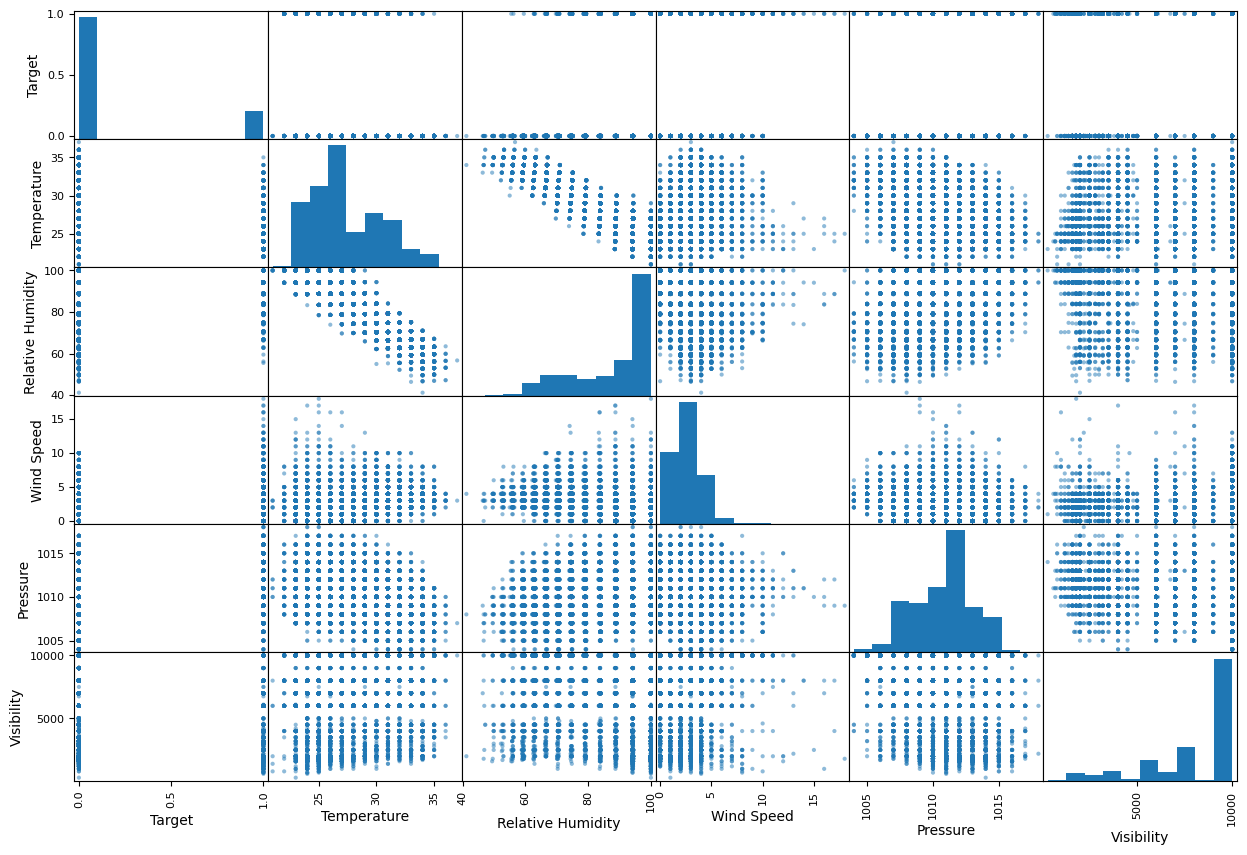

In [24]:
#Scatter matrix
scatter_matrix(df[['Target', 'Temperature','Relative Humidity','Wind Speed','Pressure','Visibility']],figsize=(15, 10))
plt.plot()
#df.plot(kind='box', subplots=True,figsize=(10, 10), layout = (3,3),sharex=False, sharey=False )

<div style="background-color: #39f98f; padding: 10px; border-left: 5px solid #059445; margin-bottom: 10px;">

We have to drop : **Visibility** because :
1. The feature has a lot of outlier
2. The feature has low negative correlation with the target 
</div>

In [25]:
df.drop("Visibility", axis = 1, inplace=True)

## 5. Summarise the training features

In [26]:
print(f"{df.head()}\n") # shows the first 5 rows of the dataframe
print(f"Number of training points: {len(df)}\n")
print(f"The unique values for the Traget: {df['Target'].unique()}\n")
print(f"The number of training points for each Target Type:\n {df['Target'].value_counts()}")

   Temperature  Relative Humidity  Wind Speed  Pressure  Target
0           26              100.0           0      1010       0
1           26              100.0           2      1009       0
2           25              100.0           2      1010       0
3           25              100.0           0      1009       0
4           25              100.0           0      1010       0

Number of training points: 23084

The unique values for the Traget: [0 1]

The number of training points for each Target Type:
 Target
0    18828
1     4256
Name: count, dtype: int64


## 6. Build Random Forest Model

### 6.1 Prepare the data for ML training

In [27]:
features = df.drop("Target", axis=1)  # get features
labels = df["Target"]                 # get target variable

# split the data
x_train, x_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.30,
    random_state=0,
    shuffle=True,
    stratify=labels
)
y_test.value_counts()

Target
0    5649
1    1277
Name: count, dtype: int64

In [28]:
x_train.shape

(16158, 4)

In [29]:
x_test.shape

(6926, 4)

### 6.2 Train model with the default parameters

In [30]:
rf = RandomForestClassifier(random_state= 0, oob_score= True)   # Initializes model with the default parameters
# Initializes model with the best parameters
#rf = RandomForestClassifier(random_state= 0, oob_score= True, max_depth=20, min_samples_leaf=20, min_samples_split=5, n_estimators=250)
model= rf.fit(x_train, y_train)   # Fit the model to the training dataset
print(f'OOB score for our model is {model.oob_score_ * 100}')

OOB score for our model is 81.79230102735488


### 6.3 Model Validation

In [31]:
# cross validation on training set
skf = StratifiedKFold(n_splits=5, shuffle= True, random_state= 42)
scores = cross_val_score(rf, x_train, y_train, cv=skf)
print(scores)
np.mean(scores)

[0.81930693 0.81652228 0.81559406 0.82327453 0.80965645]


0.8168708496894256

              precision    recall  f1-score   support

     No Rain       0.84      0.96      0.90      5649
        Rain       0.53      0.21      0.30      1277

    accuracy                           0.82      6926
   macro avg       0.69      0.58      0.60      6926
weighted avg       0.79      0.82      0.79      6926

              precision    recall  f1-score   support

     No Rain       0.84      0.96      0.90      5649
        Rain       0.53      0.21      0.30      1277

    accuracy                           0.82      6926
   macro avg       0.69      0.58      0.60      6926
weighted avg       0.79      0.82      0.79      6926



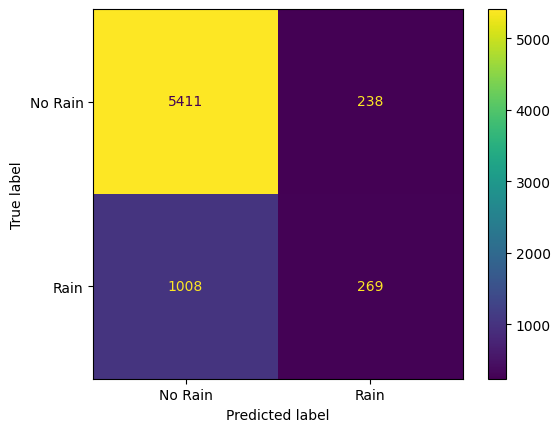

In [32]:
class_names = ["No Rain", "Rain"]
# validation on testing set
y_pred= model.predict(x_test)
#rf.score(x_test, y_test) # overall accuracy
print(classification_report(y_test, y_pred, target_names=class_names))  # Print the classification report
target_names=class_names
#print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_names))

# Plots a confusion matrix
cm = confusion_matrix(y_test, y_pred)
#disp= ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= rf.classes_)
disp= ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= class_names )
disp.plot()

## 7. Hyperparameter Tuning using GridSearchCV

### 7.1. Find the best hyperparameter using GridSearchCV

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100,150, 200,250, 300],
    'max_depth': [2,3,5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [10, 20,50, 100, 200],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

/home/duplex/anaconda3/envs/gee/lib/python3.11/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 5, 'n_estimators': 150}
Best Estimator: RandomForestClassifier(max_depth=10, min_samples_leaf=20, min_samples_split=5,
                       n_estimators=150)


### 7.2 Train model best parameters using Gridsearch

In [34]:
#rf = RandomForestClassifier(random_state= 0, oob_score= True)   # Initializes model with the default parameters
# Initializes model with the best parameters
rf = RandomForestClassifier(bootstrap = True, random_state= 0, oob_score= True, max_depth=20, min_samples_leaf=20, min_samples_split=5, n_estimators=150)
model= rf.fit(x_train, y_train)   # Fit the model to the training dataset
print(f'OOB score for our model is {model.oob_score_ * 100}')

OOB score for our model is 82.98675578660726


### 7.3 Model Validation parameters using Gridsearch

In [35]:
# cross validation on training set
skf = StratifiedKFold(n_splits=5, shuffle= True, random_state= 42)
scores = cross_val_score(rf, x_train, y_train, cv=skf)
print(scores)
np.mean(scores)

[0.83292079 0.82456683 0.83075495 0.82822656 0.82606004]


0.8285058345667435

              precision    recall  f1-score   support

     No Rain       0.84      0.97      0.90      5649
        Rain       0.60      0.20      0.30      1277

    accuracy                           0.83      6926
   macro avg       0.72      0.58      0.60      6926
weighted avg       0.80      0.83      0.79      6926

              precision    recall  f1-score   support

     No Rain       0.84      0.97      0.90      5649
        Rain       0.60      0.20      0.30      1277

    accuracy                           0.83      6926
   macro avg       0.72      0.58      0.60      6926
weighted avg       0.80      0.83      0.79      6926



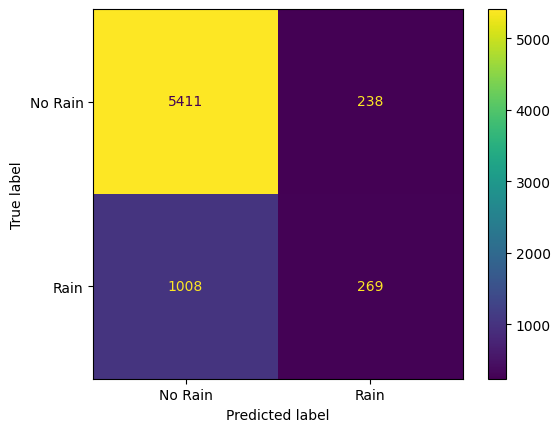

In [36]:
class_names = ["No Rain", "Rain"]
# validation on testing set
y_pred= model.predict(x_test)
#rf.score(x_test, y_test) # overall accuracy
print(classification_report(y_test, y_pred, target_names=class_names))  # Print the classification report
target_names=class_names
#print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_names))

# Plots a confusion matrix
cm = confusion_matrix(y_test, y_pred)
#disp= ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= rf.classes_)
#disp= ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= class_names )
disp.plot()

## 8. Hyperparameter Tuning using RandomizedSearchCV

### 8.1. Find the best hyperparameter  using RandomizedSearchCV

In [37]:
random_search = RandomizedSearchCV(RandomForestClassifier(),
                                   param_grid)
random_search.fit(x_train, y_train)
print(random_search.best_estimator_)

RandomForestClassifier(max_depth=20, min_samples_leaf=50, n_estimators=150)


### 8.2 Train model best parameters using RandomizedSearchCV

In [38]:
#rf = RandomForestClassifier(random_state= 0, oob_score= True)   # Initializes model with the default parameters
# Initializes model with the best parameters
rf = RandomForestClassifier(bootstrap = True, random_state= 0, oob_score= True, max_depth=10, min_samples_leaf=20, min_samples_split=5, n_estimators=150)
model= rf.fit(x_train, y_train)   # Fit the model to the training dataset
print(f'OOB score for our model is {model.oob_score_ * 100}')

OOB score for our model is 82.85678920658496


### 8.3 Model Validation parameters using RandomizedSearchCV

In [39]:
# cross validation on training set
skf = StratifiedKFold(n_splits=5, shuffle= True, random_state= 42)
scores = cross_val_score(rf, x_train, y_train, cv=skf)
print(scores)
np.mean(scores)

[0.83199257 0.82394802 0.83168317 0.82884556 0.82544104]


0.8283820721905059

              precision    recall  f1-score   support

     No Rain       0.84      0.97      0.90      5649
        Rain       0.62      0.19      0.29      1277

    accuracy                           0.83      6926
   macro avg       0.73      0.58      0.60      6926
weighted avg       0.80      0.83      0.79      6926

              precision    recall  f1-score   support

     No Rain       0.84      0.97      0.90      5649
        Rain       0.62      0.19      0.29      1277

    accuracy                           0.83      6926
   macro avg       0.73      0.58      0.60      6926
weighted avg       0.80      0.83      0.79      6926



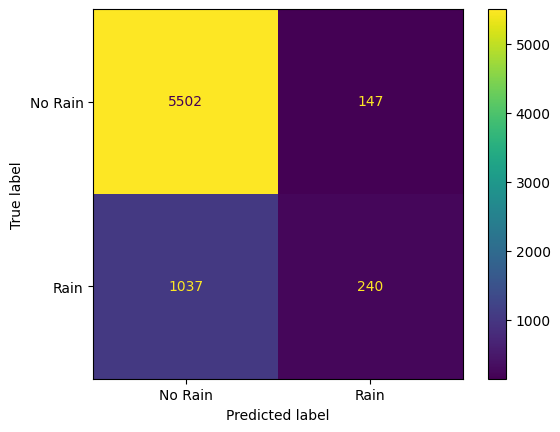

In [40]:
class_names = ["No Rain", "Rain"]
# validation on testing set
y_pred= model.predict(x_test)
#rf.score(x_test, y_test) # overall accuracy
print(classification_report(y_test, y_pred, target_names=class_names))  # Print the classification report
target_names=class_names
#print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_names))

# Plots a confusion matrix
cm = confusion_matrix(y_test, y_pred)
#disp= ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= rf.classes_)
disp= ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= class_names )
disp.plot()